In [10]:
import tensorflow as tf
import keras
from keras import ops
import numpy as np
import random
import os
import matplotlib.pyplot as plt

In [11]:
# Hyperparameters
epochs = 10
batch_size = 32
margin = 1
number_of_pairs = 1024
image_size = (100, 100)

In [12]:
class ContrastiveGenerator:
	def __init__(self, datasetPath, number_of_pairs):
		# create an empty list which will contain the subdirectory
		# names of the `dataset` directory with more than one image
		# in it
		self.number_od_pairs = number_of_pairs
		self.fruitNames = list()
		# iterate over the subdirectories in the dataset directory
		for folderName in os.listdir(datasetPath):
			# build the subdirectory name
			absoluteFolderName = os.path.join(datasetPath, folderName)
			# get the number of images in the subdirectory
			numImages = len(os.listdir(absoluteFolderName))
			# if the number of images in the current subdirectory
			# is more than one, append into the `fruitNames` list
			if numImages > 1:
				self.fruitNames.append(absoluteFolderName)
		# create a dictionary of people name to their image names
		self.allFruits = self.generate_all_fruits_dict()

	def generate_all_fruits_dict(self):
		# create an empty dictionary that will be populated with
		# directory names as keys and image names as values
		allFruits = dict()
		# iterate over all the directory names with more than one
		# image in it
		for fruit in self.fruitNames:
			# get all the image names in the current directory
			imageNames = os.listdir(fruit)
			# build the image paths and populate the dictionary
			fruitPhotos = [
				os.path.join(fruit, imageName) for imageName in imageNames
			]
			allFruits[fruit] = fruitPhotos
		# return the dictionary
		return allFruits

	def get_next_element(self):
		for _ in range(self.number_od_pairs):
			# draw a image at random which will be our anchor and
			# positive image
			anchorName = random.choice(self.fruitNames)
			# copy the list of fruit names and remove the anchor
			# from the list
			temporaryNames = self.fruitNames.copy()
			temporaryNames.remove(anchorName)
			# draw a person at random from the list of fruits without
			# the anchor, which will act as our negative sample
			negativeName = random.choice(temporaryNames)
			# draw two images from the anchor folder without replacement
			(anchorPhoto, positivePhoto) = np.random.choice(
				a=self.allFruits[anchorName],
				size=2,
				replace=False
			)
			# draw an image from the negative folder
			negativePhoto = random.choice(self.allFruits[negativeName])

			yield (anchorPhoto, positivePhoto), 1
			yield (anchorPhoto, negativePhoto), 0

In [13]:
generator = ContrastiveGenerator("/Users/filip/projekt_zespolowy/fruits-360/Training", number_of_pairs)

dataset = tf.data.Dataset.from_generator(generator.get_next_element, output_signature=((tf.TensorSpec(shape=(), dtype=tf.string), 
                                                                                        tf.TensorSpec(shape=(), dtype=tf.string)),
                                                                                        tf.TensorSpec(shape=(), dtype=tf.float32)))

def decode_and_resize(paths, label):

    img0 = tf.io.read_file(paths[0])
    img0 = tf.image.decode_jpeg(img0, channels=3)
    img0 = tf.image.resize(img0, image_size)
    img0 = tf.image.convert_image_dtype(img0, tf.float32)

    img1 = tf.io.read_file(paths[1])
    img1 = tf.image.decode_jpeg(img1, channels=3)
    img1 = tf.image.resize(img1, image_size)
    img1 = tf.image.convert_image_dtype(img1, tf.float32)

    return (img0, img1), label


train_dataset = dataset.map(decode_and_resize)
train_dataset = train_dataset.batch(batch_size)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

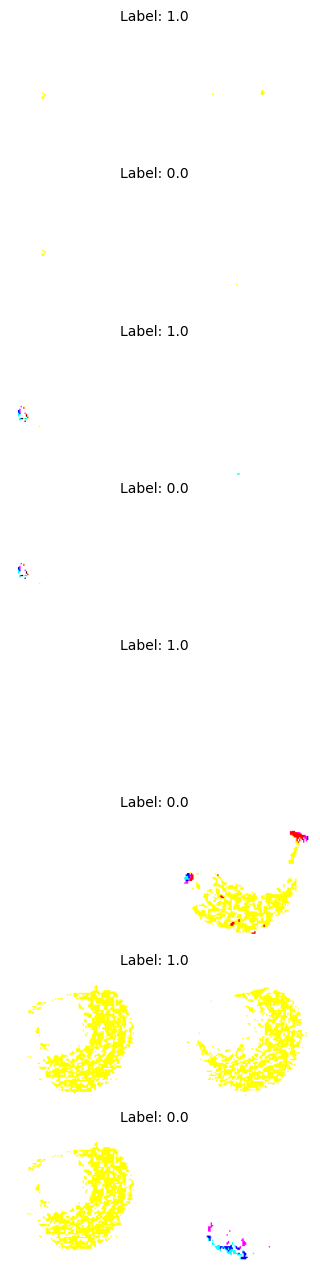

In [14]:
# Visualize some images
def visualize(batch, num_pairs=4):
    # Taking images and labels from batch
    (images0, images1), labels = batch
    
    fig, axes = plt.subplots(num_pairs, 2, figsize=(4, num_pairs * 2))
    
    for i in range(num_pairs):
        # Display first image
        ax = axes[i, 0]
        ax.imshow(images0[i])
        ax.axis('off')
        
        # Add text with label
        ax.text(1.1, 1.1, f'Label: {labels[i]}', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        
        # Display second image
        ax = axes[i, 1]
        ax.imshow(images1[i])
        ax.axis('off')
                
    plt.show()


train_dataset_iterator = iter(train_dataset)
batch = next(train_dataset_iterator)
visualize(batch, 8)

In [15]:
# Provided two tensors t1 and t2
# Euclidean distance = sqrt(sum(square(t1-t2)))
def euclidean_distance(vects):
    """Find the Euclidean distance between two vectors.

    Arguments:
        vects: List containing two tensors of same length.

    Returns:
        Tensor containing euclidean distance
        (as floating point value) between vectors.
    """

    x, y = vects
    sum_square = ops.sum(ops.square(x - y), axis=1, keepdims=True)
    return ops.sqrt(ops.maximum(sum_square, keras.backend.epsilon()))


input = keras.layers.Input((100, 100, 3))
x = keras.layers.BatchNormalization()(input)
x = keras.layers.Conv2D(16, (5, 5), activation="tanh")(x)
x = keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
x = keras.layers.Conv2D(32, (5, 5), activation="tanh")(x)
x = keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
x = keras.layers.Flatten()(x)

x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dense(10, activation="tanh")(x)
embedding_network = keras.Model(input, x)


input_1 = keras.layers.Input((100, 100, 3))
input_2 = keras.layers.Input((100, 100, 3))

# As mentioned above, Siamese Network share weights between
# tower networks (sister networks). To allow this, we will use
# same embedding network for both tower networks.
tower_1 = embedding_network(input_1)
tower_2 = embedding_network(input_2)

merge_layer = keras.layers.Lambda(euclidean_distance, output_shape=(1,))(
    [tower_1, tower_2]
)
normal_layer = keras.layers.BatchNormalization()(merge_layer)
output_layer = keras.layers.Dense(1, activation="sigmoid")(normal_layer)
siamese = keras.Model(inputs=[input_1, input_2], outputs=output_layer)

In [16]:
def loss(margin=1):
    """Provides 'contrastive_loss' an enclosing scope with variable 'margin'.

    Arguments:
        margin: Integer, defines the baseline for distance for which pairs
                should be classified as dissimilar. - (default is 1).

    Returns:
        'contrastive_loss' function with data ('margin') attached.
    """

    # Contrastive loss = mean( (1-true_value) * square(prediction) +
    #                         true_value * square( max(margin-prediction, 0) ))
    def contrastive_loss(y_true, y_pred):
        """Calculates the contrastive loss.

        Arguments:
            y_true: List of labels, each label is of type float32.
            y_pred: List of predictions of same length as of y_true,
                    each label is of type float32.

        Returns:
            A tensor containing contrastive loss as floating point value.
        """

        square_pred = ops.square(y_pred)
        margin_square = ops.square(ops.maximum(margin - (y_pred), 0))
        return ops.mean((1 - y_true) * square_pred + (y_true) * margin_square)

    return contrastive_loss

In [17]:
siamese.compile(loss=loss(margin=margin), optimizer="RMSprop", metrics=["accuracy"])
siamese.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_5        │ (None, 10)        │    230,902 │ input_layer_4[0]… │
│ (Functional)        │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ functional_5[0][… │
│                     │                   │            │ functional_5[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1)         │          4 │ lambda_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │          2 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 230,908 (901.98 KB)

 Trainable params: 199,924 (780.95 KB)

 Non-trainable params: 30,984 (121.03 KB)

In [18]:
history = siamese.fit(
    train_dataset,
    batch_size=batch_size,
    epochs=epochs,
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - accuracy: 0.2626 - loss: 0.4488
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.3993 - loss: 0.3534
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.3747 - loss: 0.3543
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.4125 - loss: 0.3344
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.3914 - loss: 0.3233
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.3735 - loss: 0.3144
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.4449 - loss: 0.2846
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.4158 - loss: 0.2861
Epoch 9/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.4362 - loss: 0.2772
Epoch 10/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.4371 - loss: 0.2682


KeyError: 'val_accuracy'

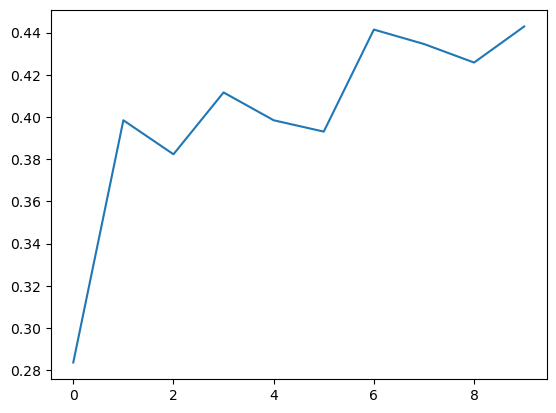

In [19]:
def plt_metric(history, metric, title, has_valid=True):
    """Plots the given 'metric' from 'history'.

    Arguments:
        history: history attribute of History object returned from Model.fit.
        metric: Metric to plot, a string value present as key in 'history'.
        title: A string to be used as title of plot.
        has_valid: Boolean, true if valid data was passed to Model.fit else false.

    Returns:
        None.
    """
    plt.plot(history[metric])
    if has_valid:
        plt.plot(history["val_" + metric])
        plt.legend(["train", "validation"], loc="upper left")
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel("epoch")
    plt.show()


# Plot the accuracy
plt_metric(history=history.history, metric="accuracy", title="Model accuracy")

# Plot the contrastive loss
plt_metric(history=history.history, metric="loss", title="Contrastive Loss")